In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv(r'clean_orders.csv', parse_dates=['order_purchase_timestamp'])
print(f"Shape: {df.shape}")
df.head()

Shape: (115723, 25)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,payment_type,payment_value,review_score,delivery_delay_days,order_month,order_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,credit_card,18.12,4.0,-8.0,2017-10,2017
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,voucher,2.00,4.0,-8.0,2017-10,2017
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,voucher,18.59,4.0,-8.0,2017-10,2017
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumery,boleto,141.46,4.0,-6.0,2018-07,2018
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,auto,credit_card,179.12,5.0,-18.0,2018-08,2018


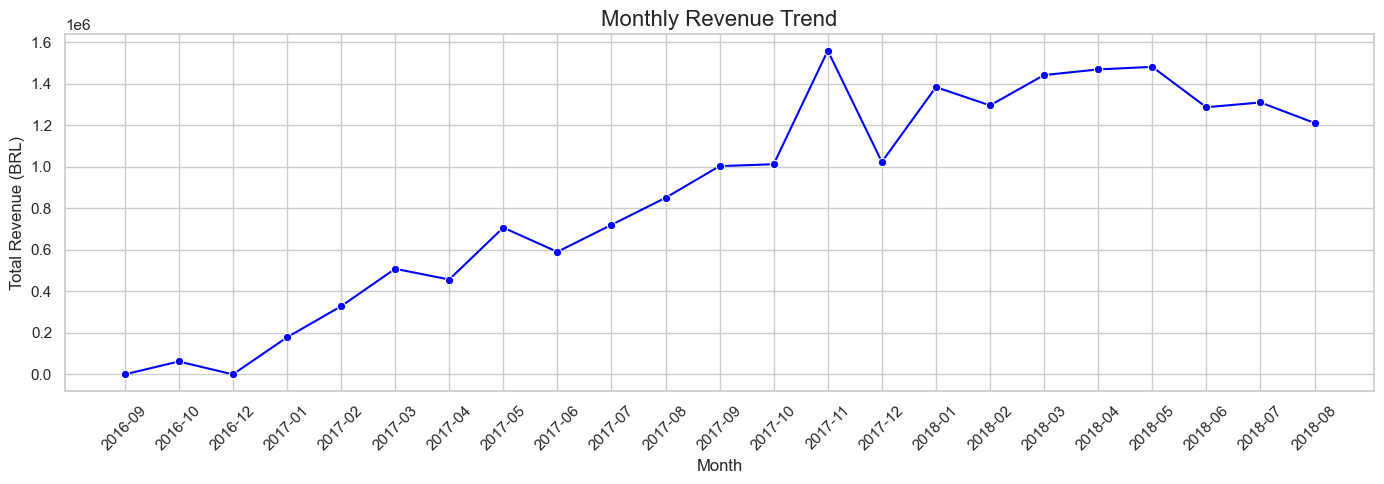

In [11]:
monthly_revenue = df.groupby('order_month')['payment_value'].sum().reset_index()
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_revenue, x='order_month', y='payment_value', marker='o', color='blue')
plt.title('Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\shirl\OneDrive\Desktop\ecommerce-analytics\data\monthly_revenue.png', dpi=150)
plt.show()

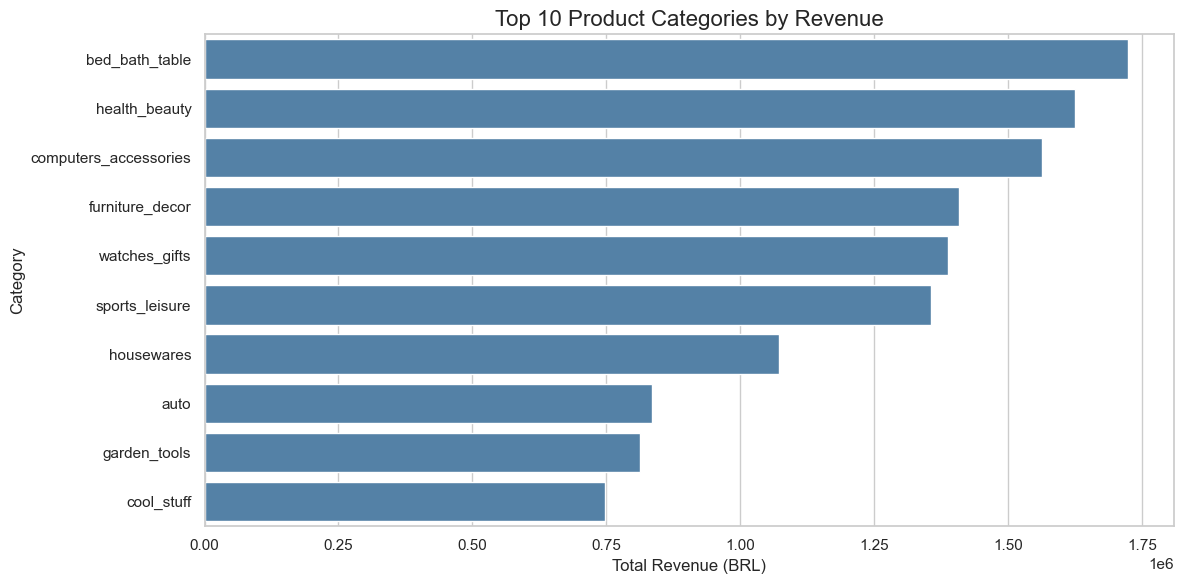

In [12]:
top_categories = (
    df.groupby('product_category_name_english')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x='payment_value', y='product_category_name_english', color='steelblue')
plt.title('Top 10 Product Categories by Revenue', fontsize=16)
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(r'C:\Users\shirl\OneDrive\Desktop\ecommerce-analytics\data\top_categories.png', dpi=150)
plt.show()

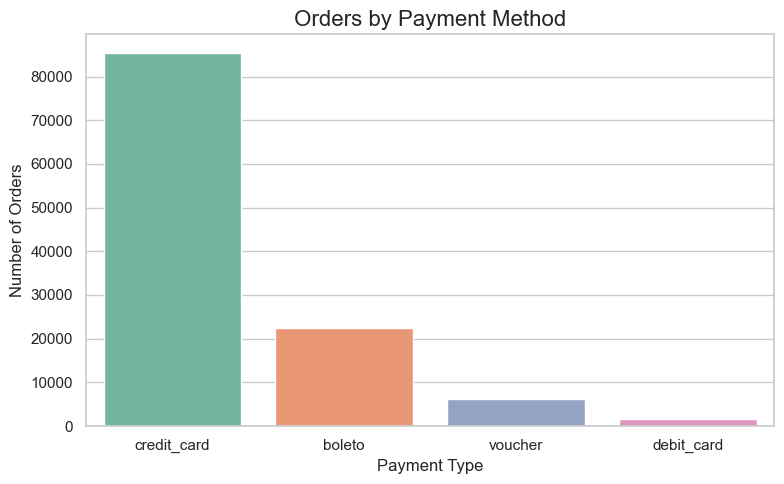

In [14]:
payment_counts = df['payment_type'].value_counts().reset_index()
payment_counts.columns = ['payment_type', 'count']

plt.figure(figsize=(8, 5))
sns.barplot(data=payment_counts, x='payment_type', y='count', palette='Set2', hue='payment_type',legend=False)
plt.title('Orders by Payment Method', fontsize=16)
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(r'C:\Users\shirl\OneDrive\Desktop\ecommerce-analytics\data\payment_methods.png', dpi=150)
plt.show()

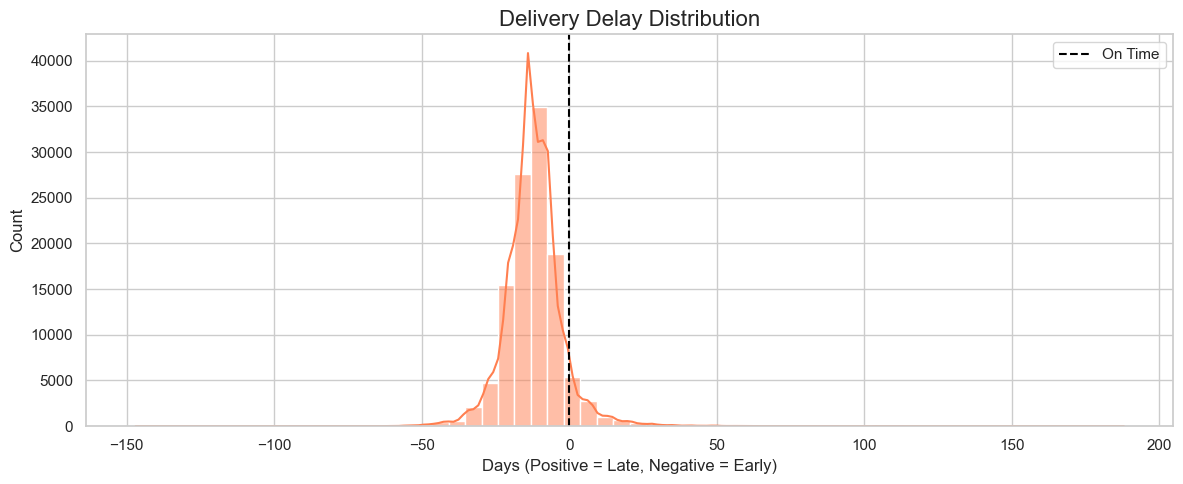

Late deliveries: 7558 (6.5%)
On time / Early: 108157 (93.5%)


In [15]:
plt.figure(figsize=(12, 5))
sns.histplot(df['delivery_delay_days'].dropna(), bins=60, kde=True, color='coral')
plt.axvline(0, color='black', linestyle='--', label='On Time')
plt.title('Delivery Delay Distribution', fontsize=16)
plt.xlabel('Days (Positive = Late, Negative = Early)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\shirl\OneDrive\Desktop\ecommerce-analytics\data\delivery_delay.png', dpi=150)
plt.show()

late = (df['delivery_delay_days'] > 0).sum()
early = (df['delivery_delay_days'] <= 0).sum()
print(f"Late deliveries: {late} ({late/len(df)*100:.1f}%)")
print(f"On time / Early: {early} ({early/len(df)*100:.1f}%)")

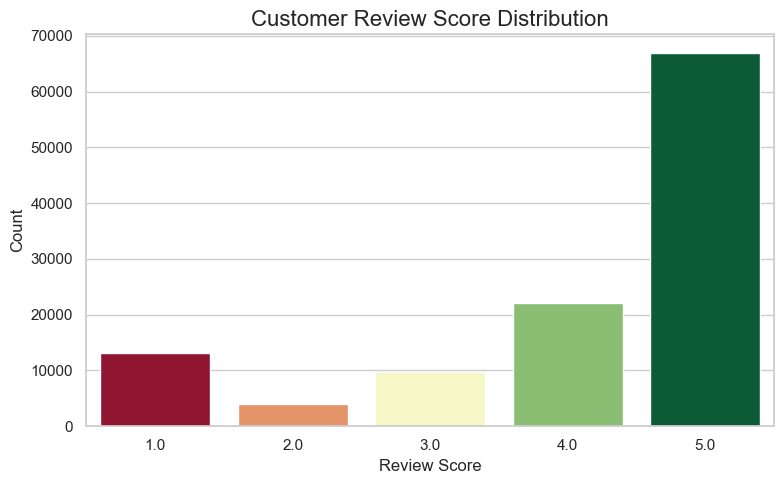

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='review_score', palette='RdYlGn', hue='review_score', legend=False)
plt.title('Customer Review Score Distribution', fontsize=16)
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(r'C:\Users\shirl\OneDrive\Desktop\ecommerce-analytics\data\review_scores.png', dpi=150)
plt.show()

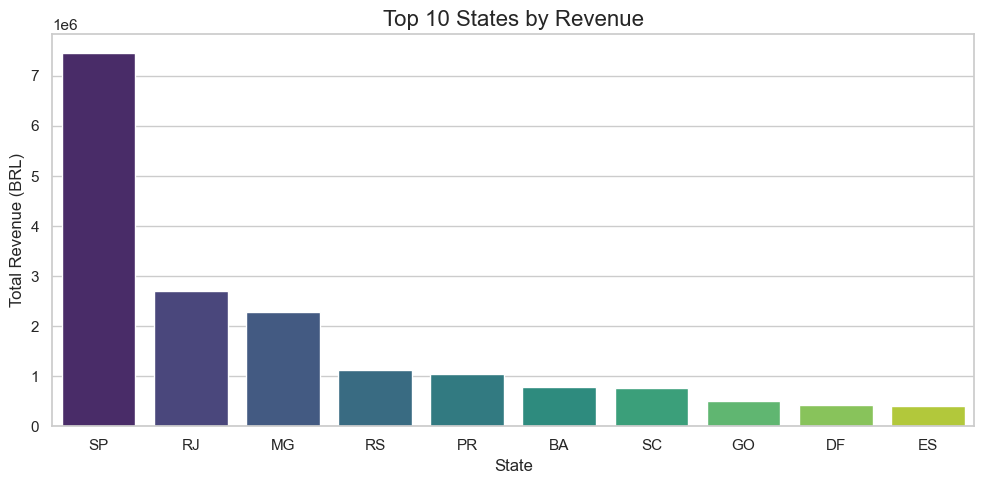

In [19]:
top_states = (
    df.groupby('customer_state')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_states, x='customer_state', y='payment_value', palette='viridis', hue='customer_state', legend=False)
plt.title('Top 10 States by Revenue', fontsize=16)
plt.xlabel('State')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig(r'C:\Users\shirl\OneDrive\Desktop\ecommerce-analytics\data\revenue_by_state.png', dpi=150)
plt.show()

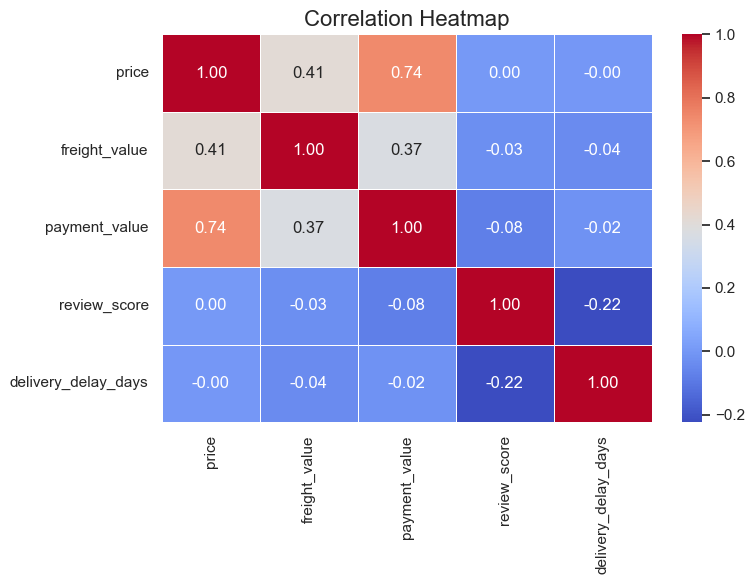

In [20]:
numeric_cols = df[['price', 'freight_value', 'payment_value', 'review_score', 'delivery_delay_days']].dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig(r'C:\Users\shirl\OneDrive\Desktop\ecommerce-analytics\data\correlation_heatmap.png', dpi=150)
plt.show()

In [21]:
print("KEY BUSINESS INSIGHTS")
print(f"Total Revenue:        BRL {df['payment_value'].sum():,.2f}")
print(f"Total Orders:         {df['order_id'].nunique():,}")
print(f"Total Customers:      {df['customer_id'].nunique():,}")
print(f"Avg Order Value:      BRL {df['payment_value'].mean():,.2f}")
print(f"Avg Review Score:     {df['review_score'].mean():.2f} / 5")
print(f"Late Delivery Rate:   {(df['delivery_delay_days'] > 0).mean()*100:.1f}%")
print(f"Top Category:         {top_categories.iloc[0]['product_category_name_english']}")
print(f"Top State:            {top_states.iloc[0]['customer_state']}")

KEY BUSINESS INSIGHTS
Total Revenue:        BRL 19,881,945.07
Total Orders:         96,478
Total Customers:      96,478
Avg Order Value:      BRL 171.81
Avg Review Score:     4.09 / 5
Late Delivery Rate:   6.5%
Top Category:         bed_bath_table
Top State:            SP
